# 📱 Predict Customer Churn — Kaggle Playground S6E3

## Why Does Churn Matter?
Acquiring a new customer costs **5x more** than retaining an existing one.
Every churned customer = lost revenue + acquisition cost to replace them.

This notebook is a **complete beginner-friendly guide** to:
- Understanding what drives customer churn
- Building a model to predict it
- Submitting to the Kaggle leaderboard

### Dataset
- 594,194 customers from a telecom company
- 21 features covering demographics, services, and billing
- Goal: Predict if a customer will churn (Yes/No)

## 📦 Importing Libraries
Essential libraries for data analysis, visualization and machine learning.

In [21]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

# Display settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📂 Loading the Dataset
Loading train and test data from the competition.

In [22]:
# Load train and test datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

## 🔍 Data Overview
Let's understand the structure, missing values, and target distribution.

In [23]:
print(train.columns.tolist())
print(f"\nTrain: {train.shape}")
print(f"Test: {test.shape}")
print(f"\nMissing values:\n{train.isnull().sum()}")
print(f"\nChurn distribution:\n{train['Churn'].value_counts()}")
print(f"\nChurn Rate: {(train['Churn']=='Yes').mean()*100:.2f}%")

['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Train: (594194, 21)
Test: (254655, 20)

Missing values:
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     460377
Yes    133817
Name: count, dtype: int64

Churn Rate: 22.52%


## 🎯 Target Variable — Churn Distribution

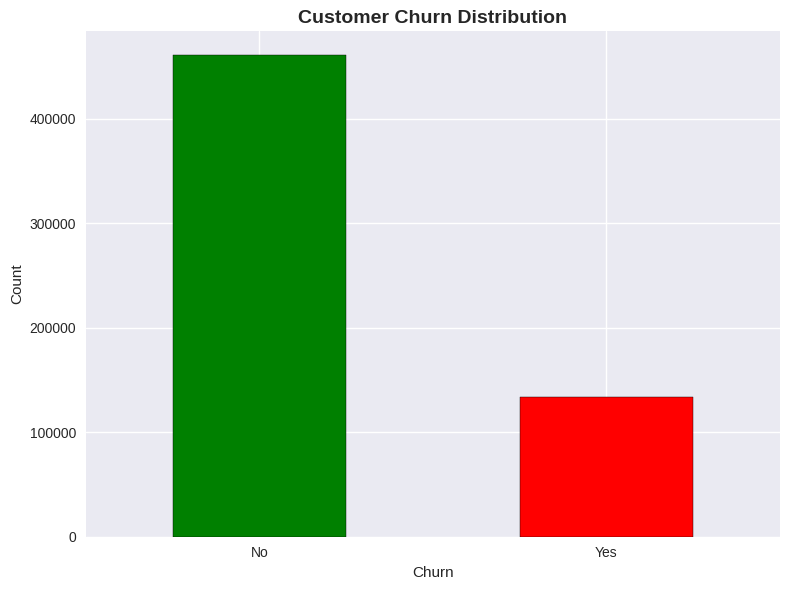

In [24]:
# Churn Distribution visualization
plt.figure(figsize=(8,6))
train['Churn'].value_counts().plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 💡 Insight
**Only 22.52% of customers churn — imbalanced dataset!**
- No Churn → 460,377 customers (77.48%)
- Churn    → 133,817 customers (22.52%)

This imbalance means accuracy is misleading as a metric.
A model predicting "No" for everyone scores 77% accuracy 
but catches ZERO churners — useless for business!
We use **ROC-AUC** instead which handles imbalance properly.

## 📋 Contract Type vs Churn
Does contract length affect churn? Let's find out.

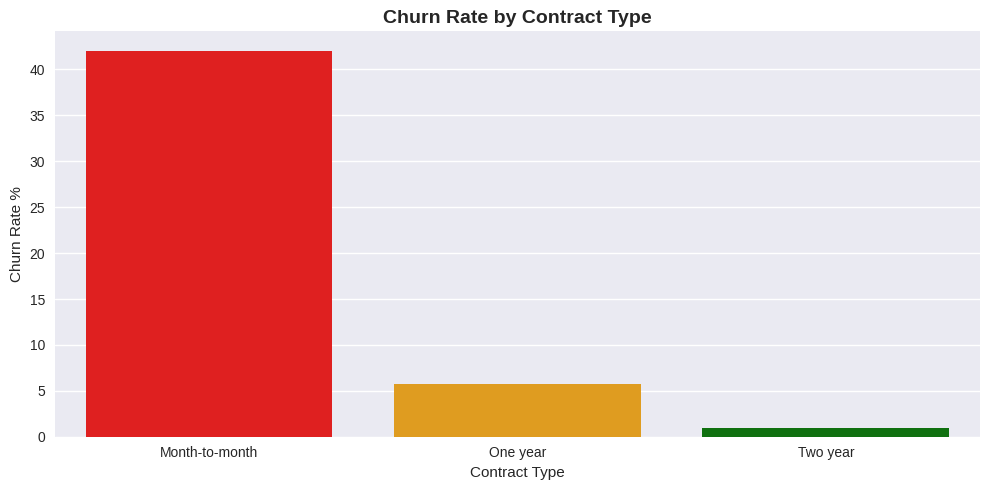

         Contract  Churn Rate %
0  Month-to-month     42.054343
1        One year      5.762787
2        Two year      0.998165


In [25]:
plt.figure(figsize=(10,5))
# Calculating Churn rate by Contract type
contract_churn = train.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate %']

sns.barplot(data=contract_churn, x='Contract', y='Churn Rate %', hue='Contract', palette= ['red', 'orange', 'green' ])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate %')
plt.tight_layout()
plt.show()

print(contract_churn)

### 💡 Insight
**Contract type is the strongest business predictor of churn!**
- Month-to-month customers churn at **42%** — alarming!
- One year contract drops churn to just **5.76%**
- Two year contract drops churn to under **1%**

**Business Recommendation:**
- Incentivize customers to switch from month-to-month 
- to annual contracts — even a small discount pays off.
- Converting a monthly customer to yearly reduces churn probability by 7x!

## ⏳ Tenure vs Churn
Do newer customers churn more than loyal ones?

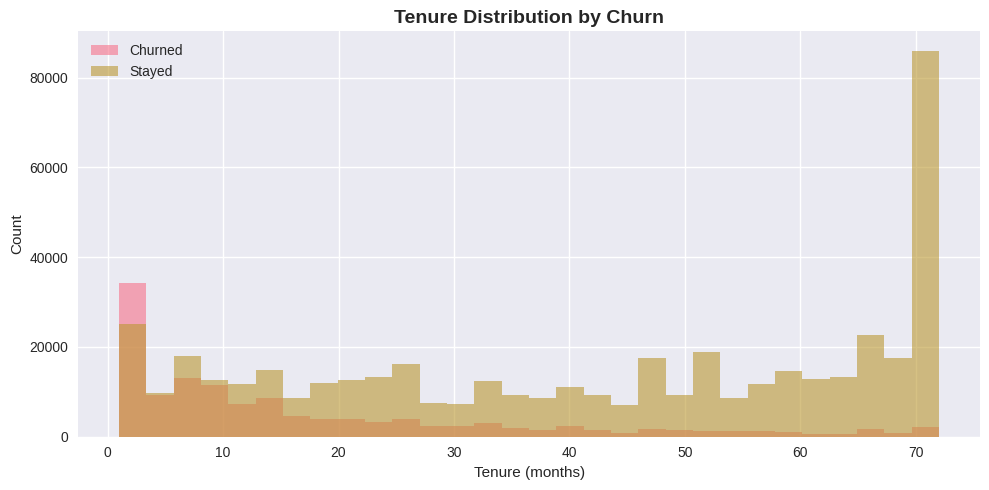

Churn
No     42.231313
Yes    17.125343
Name: tenure, dtype: float64


In [26]:
plt.figure(figsize=(10,5))
# Plot Tenure Distribution by Churn Status
for churn in ['Yes', 'No']:
    subset = train[train['Churn']==churn]['tenure']
    subset.hist(alpha=0.6, label=churn, bins=30)

plt.title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend(['Churned', 'Stayed'])
plt.tight_layout()
plt.show()

print(train.groupby('Churn')['tenure'].mean())

### 💡 Insight
**New customers churn — loyal customers stay!**
- Churned customers average only **17 months** tenure
- Stayed customers average **42 months** tenure

The first 6 months are critical — highest churn risk period.
If a customer survives past 2 years, they almost never leave.

**Business Recommendation:**
> Focus retention efforts on customers in their 
> first 6 months — onboarding experience is everything!

## 💰 Monthly Charges vs Churn
Do higher bills cause customers to leave?

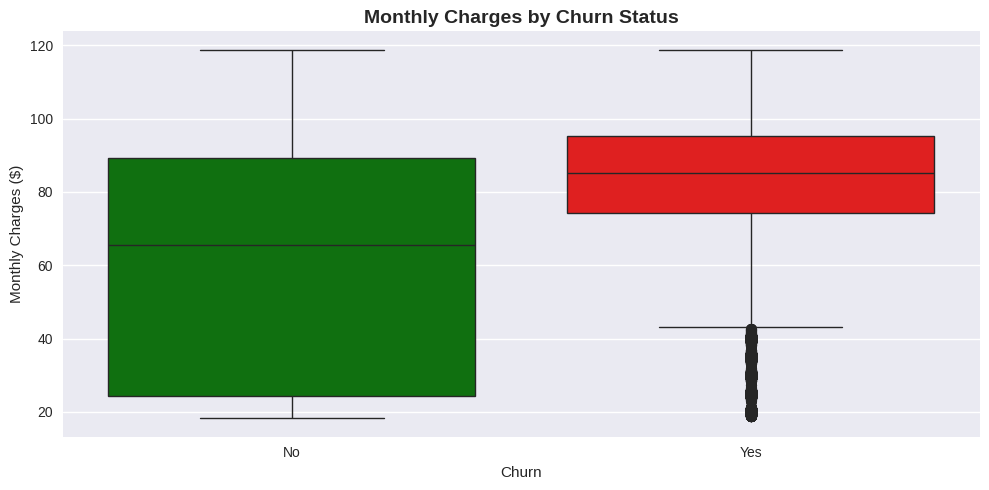

Churn
No     61.293633
Yes    81.597525
Name: MonthlyCharges, dtype: float64


In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=train, x='Churn', y='MonthlyCharges',
            hue='Churn', palette=['green','red'], legend=False)
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print(train.groupby('Churn')['MonthlyCharges'].mean())

### 💡 Insight
**Customers paying more are more likely to churn!**
- Stayed customers pay avg **$61/month**
- Churned customers pay avg **$81/month** — 33% more!

Higher charges combined with month-to-month contracts 
is the most dangerous combination for churn.

**Business Recommendation:**
> Offer loyalty discounts to high-paying month-to-month 
> customers before they leave — they are your highest risk group.


## 🔧 Feature Engineering
Converting categorical columns to numbers so our model can understand them.

In [28]:
# Combining train and test for consistent encoding
train['is_train'] = 1
test['is_train'] = 0
test['Churn'] = 'No' # placeholder

combined = pd.concat([train, test], axis=0).reset_index(drop=True)

# Dropping id column
combined = combined.drop('id', axis=1)

# Encoding target
combined['Churn'] = (combined['Churn'] == 'Yes').astype(int)

# Label encoding to all object columns 
le = LabelEncoder()
for col in combined.select_dtypes(include='object').columns:
    combined[col]= le.fit_transform(combined[col])

print('Encoding done!')
print(combined.shape)

Encoding done!
(848849, 21)


## ✂️ Splitting Back & Preparing for Model
Separating combined data back into train and test sets.

In [29]:
# Split back into train and test
train_encoded = combined[combined['is_train'] == 1].drop('is_train', axis=1)
test_encoded = combined[combined['is_train'] == 0].drop(['is_train', 'Churn'], axis=1)

# Features and target
X = train_encoded.drop('Churn', axis=1)
y = train_encoded['Churn']

# Training test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
test_scaled = scaler.transform(test_encoded)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Test: {test_scaled.shape}")
print("✅ Ready for modeling!")

X_train: (475355, 19)
X_test: (118839, 19)
Test: (254655, 19)
✅ Ready for modeling!


## 🤖 Model Building
Training 3 models and comparing performance.

In [31]:
# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]
print(f"Logistic Regression → Accuracy: {accuracy_score(y_test, lr_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print(f"Random Forest       → Accuracy: {accuracy_score(y_test, rf_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")

# 3. XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]
print(f"XGBoost             → Accuracy: {accuracy_score(y_test, xgb_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

Logistic Regression → Accuracy: 0.8549 | ROC-AUC: 0.9058
Random Forest       → Accuracy: 0.8471 | ROC-AUC: 0.8962
XGBoost             → Accuracy: 0.8616 | ROC-AUC: 0.9152


## 📤 Submission

In [32]:
# Generate predictions on test data
test_preds = xgb.predict_proba(test_scaled)[:,1]

# Create submission file
submission = pd.read_csv('sample_submission.csv')
submission['Churn'] = test_preds

submission.to_csv('submission.csv', index=False)
print("✅ Submission saved!")
print(submission.head())

✅ Submission saved!
       id     Churn
0  594194  0.062558
1  594195  0.001287
2  594196  0.093851
3  594197  0.003023
4  594198  0.495137


### 📊 Model Results
| Model | Accuracy | ROC-AUC |
|-------|----------|---------|
| Logistic Regression | 85.49% | 0.9058 |
| Random Forest | 84.71% | 0.8962 |
| **XGBoost** | **86.16%** | **0.9152** ✅ |

### 💡 Top Findings
1. **Contract type** is the #1 churn predictor — 42% churn on month-to-month vs 1% on two-year
2. **New customers churn most** — average tenure of churned customers is only 17 months
3. **Higher bills = more churn** — churned customers pay $81/month vs $61 for loyal customers
4. **Imbalanced dataset** — always use ROC-AUC, not accuracy for churn problems

### 🎯 Business Recommendations
- Offer discounts to convert month-to-month customers to annual contracts
- Focus retention on first 6 months — highest risk period
- Target high-paying customers with loyalty rewards before they leave

### 🚀 Next Steps
- Try hyperparameter tuning with Optuna
- Add interaction features between Contract + MonthlyCharges
- Try ensemble of XGBoost + LightGBM

---